In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("../../Data/CSV/silver_prices_10years.csv")


In [133]:
# 1️⃣ สร้าง Target ก่อน
data['Target'] = data['Close'].shift(-1)

# 2️⃣ ลบแถวสุดท้ายที่เป็น NaN
data = data.dropna()

# 3️⃣ สร้าง X และ y


X = np.array(data[['Open', 'High', 'Low', 'Volume']])
y = np.array(data['Target'])
data['Target'] = data['Close'].shift(-1)

In [134]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# 1️⃣ split ก่อน
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 2️⃣ สร้าง scaler
scaler = StandardScaler()

# 3️⃣ fit เฉพาะ X_train
X_train_scaled = scaler.fit_transform(X_train)

# 4️⃣ transform X_test (ห้าม fit ซ้ำ)
X_test_scaled = scaler.transform(X_test)

# 5️⃣ train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 6️⃣ predict
y_pred = model.predict(X_test_scaled)


In [135]:

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(r2)

0.9952189947438915


In [136]:
results = pd.DataFrame({
    "Metric": ["R2", "MAE", "MSE", "RMSE"],
    "Linear Regression": [r2, mae, mse, rmse]
})



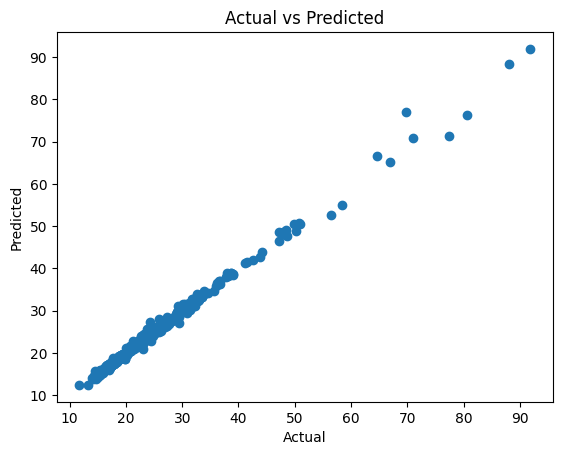

In [137]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()


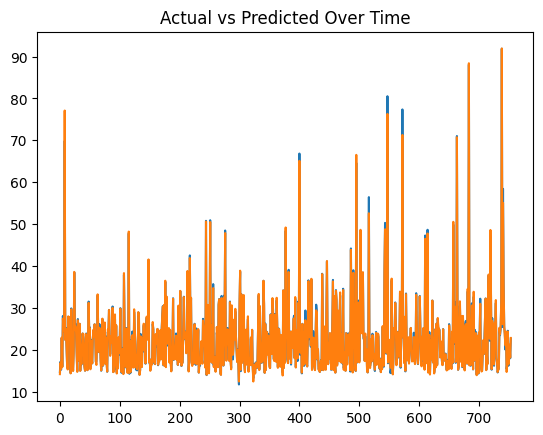

In [138]:
plt.figure()
plt.plot(y_test)
plt.plot(y_pred)
plt.title("Actual vs Predicted Over Time")
plt.show()


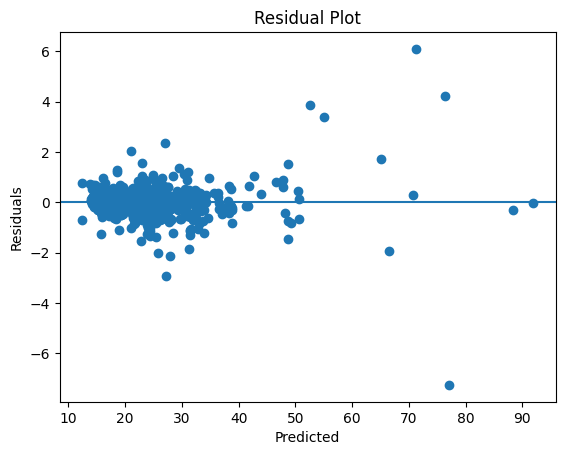

In [139]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()
